In [264]:
##-- load libraries --##
import numpy as np
import pandas as pd
from lifelines import KaplanMeierFitter
from lifelines import CoxPHFitter
import matplotlib.pyplot as plt
import pyreadr

import warnings
warnings.filterwarnings("ignore")

In [265]:
##-- INDEX EVENT -> BORROW --##
# read the .rds file and extract the dataframe (RDS may contain only one object)
result = pyreadr.read_r("/home/dgxuser40/manjil/finsurv/Data/Survival_Data/Borrow/X_train/X_train_1.rds")
dfx = list(result.values())[0]
dfx.head(1)

,id,type,timestamp,user,pool,reserve,amount,amountUSD,amountETH,borrowRate,...,sinDayOfQuarter,cosDayOfQuarter,sinDayOfYear,cosDayOfYear,sinQuarter,cosQuarter,isWeekend,logAmount,logAmountUSD,logAmountETH
0,0xc70f4c3f447f6a88e9fbb87ac1394b589e469ee57dda...,borrow,1.606841e+09,0xbd723fc4f1d737dcfc48a07fe7336766d34cad5f,0xb53c1a33016b2dc2ff3653530bff1848a515c8c5,DAI,1.0,1.001646,0.00214,1.25,...,-0.957253,-0.289252,-0.478734,0.87796,-2.449294e-16,1.0,FALSE,0.693147,0.69397,0.002138


In [266]:
len(dfx['id'])

40457

In [267]:
##-- INDEX EVENT -> BORROW & OUTCOME EVENT -> LIQUIDATED --##
result = pyreadr.read_r("/home/dgxuser40/manjil/finsurv/Data/Survival_Data/Borrow/Account Liquidated/y_train.rds")
dfy = list(result.values())[0]
dfy.head(1)

,timeDiff,status,id,Index Event,Outcome Event
0,49806576.0,0.0,0xc70f4c3f447f6a88e9fbb87ac1394b589e469ee57dda...,borrow,account liquidated


In [268]:
len(dfy['id'])

161826

In [269]:
dfx.shape, dfy.shape

((40457, 129), (161826, 5))

In [270]:
# merge on 'id', keep only matching rows
merged_df = pd.merge(dfx, dfy, on='id', how='inner')

In [271]:
merged_df.shape

(41245, 133)

### Non-parametric model [Kaplan Meier Curve]

Text(0, 0.5, 'Probability')

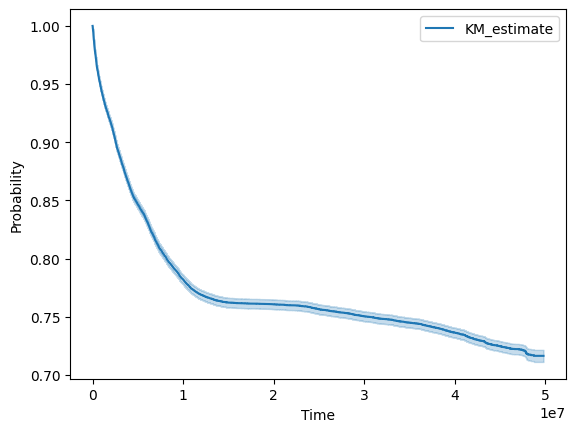

In [272]:
T = merged_df["timeDiff"]
E = merged_df["status"] # 0 or 1

kmf = KaplanMeierFitter()
kmf.fit(durations = T, event_observed = E)
kmf.plot_survival_function()
plt.xlabel('Time')
plt.ylabel('Probability')

<Axes: xlabel='timeline'>

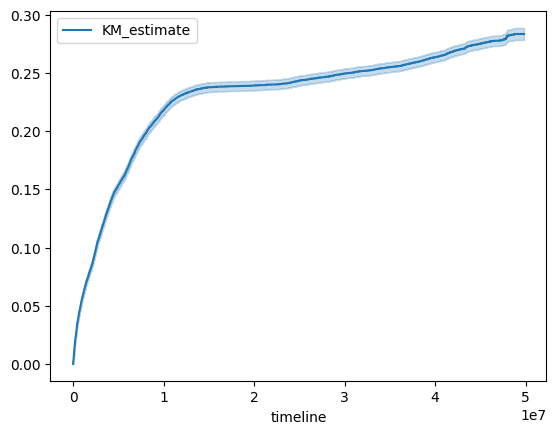

In [273]:
# plots the cumulative density function (CDF) of events over time.
kmf.plot_cumulative_density()

### Cox Proportional Hazard Model

In [274]:
merged_df.head()

,id,type,timestamp,user,pool,reserve,amount,amountUSD,amountETH,borrowRate,...,sinQuarter,cosQuarter,isWeekend,logAmount,logAmountUSD,logAmountETH,timeDiff,status,Index Event,Outcome Event
0,0xc70f4c3f447f6a88e9fbb87ac1394b589e469ee57dda...,borrow,1.606841e+09,0xbd723fc4f1d737dcfc48a07fe7336766d34cad5f,0xb53c1a33016b2dc2ff3653530bff1848a515c8c5,DAI,1.00,1.001646,0.002140,1.250000,...,-2.449294e-16,1.0,FALSE,0.693147,0.693970,0.002138,49806576.0,0.0,borrow,account liquidated
1,0x1ee3db904548c16d2ed3572f3d9894652e031facc8fa...,borrow,1.606902e+09,0x21d05071ca08593e13cd3afd0b4869537e015c92,0xb53c1a33016b2dc2ff3653530bff1848a515c8c5,DAI,1.00,1.001646,0.002140,2.500015,...,-2.449294e-16,1.0,FALSE,0.693147,0.693970,0.002138,49746136.0,0.0,borrow,account liquidated
2,0x1e8f85330edc5005ead7a7ae8c418fbb64df726d4ffc...,borrow,1.606905e+09,0x39d637737cc76c5849a52c7d3b872a1eb22aa71c,0xb53c1a33016b2dc2ff3653530bff1848a515c8c5,LINK,1.00,12.761559,0.027269,67.635468,...,-2.449294e-16,1.0,FALSE,0.693147,2.621879,0.026904,49743104.0,0.0,borrow,account liquidated
3,0x43136c7aba13c072bb19ed88f8eadf859f0bfb994b42...,borrow,1.606913e+09,0x39d637737cc76c5849a52c7d3b872a1eb22aa71c,0xb53c1a33016b2dc2ff3653530bff1848a515c8c5,AAVE,0.05,3.604718,0.007703,0.000000,...,-2.449294e-16,1.0,FALSE,0.048790,1.527081,0.007673,49734553.0,0.0,borrow,account liquidated
4,0xd96af0cf05a1e99125fe51ee7e27a1c96cf40ea6e596...,borrow,1.606915e+09,0xdad4c11e8cc6a5c37808d3b31b3b284809f702d1,0xb53c1a33016b2dc2ff3653530bff1848a515c8c5,DAI,1.00,1.001646,0.002140,0.141511,...,-2.449294e-16,1.0,FALSE,0.693147,0.693970,0.002138,49733175.0,0.0,borrow,account liquidated


In [275]:
new_df = merged_df[['timeDiff', 'status', 'amount', 'amountUSD', 'amountETH', 'borrowRate', 'logAmount', 'logAmountUSD', 'logAmountETH']]
new_df.head()

,timeDiff,status,amount,amountUSD,amountETH,borrowRate,logAmount,logAmountUSD,logAmountETH
0,49806576.0,0.0,1.00,1.001646,0.002140,1.250000,0.693147,0.693970,0.002138
1,49746136.0,0.0,1.00,1.001646,0.002140,2.500015,0.693147,0.693970,0.002138
2,49743104.0,0.0,1.00,12.761559,0.027269,67.635468,0.693147,2.621879,0.026904
3,49734553.0,0.0,0.05,3.604718,0.007703,0.000000,0.048790,1.527081,0.007673
4,49733175.0,0.0,1.00,1.001646,0.002140,0.141511,0.693147,0.693970,0.002138


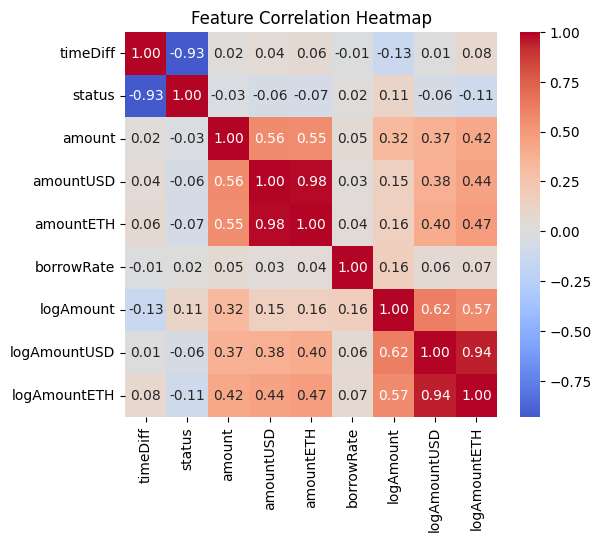

In [276]:
import seaborn as sns

corr = new_df.corr()
plt.figure(figsize=(6,5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', center=0)
plt.title("Feature Correlation Heatmap")
plt.show()

In [277]:
from lifelines import CoxPHFitter

cph = CoxPHFitter()
cph.fit(new_df, duration_col='timeDiff', event_col='status')
cph.print_summary()

<lifelines.CoxPHFitter: fitted with 41245 total observations, 30041 right-censored observations>
             duration col = 'timeDiff'
                event col = 'status'
      baseline estimation = breslow
   number of observations = 41245
number of events observed = 11204
   partial log-likelihood = -115450.77
         time fit was run = 2025-09-15 21:43:52 UTC

---
              coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                     
amount        0.00      1.00      0.00            0.00            0.00                1.00                1.00
amountUSD     0.00      1.00      0.00           -0.00            0.00                1.00                1.00
amountETH    -0.00      1.00      0.00           -0.00           -0.00                1.00                1.00
borrowRate   -0.00      1.00      0.00           -0.00           -0.00                1.00                1.00
logAmount     0.29      1.34      0.01            0.27            0.31                1.31                1.36
logAmountUSD  0.16      1.17      0.02            0.11            0.20                1.12                1.23
logAmountETH -0.67      0.51      0.03           -0.72           -0.62                0.48                0.54

              cmp to      z      p  -log2(p)
covariate                                   
amount          0.00   3.06 <0.005      8.81
amountUSD       0.00   0.54   0.59      0.77
amountETH       0.00  -5.23 <0.005     22.50
borrowRate      0.00  -2.06   0.04      4.68
logAmount       0.00  29.33 <0.005    625.67
logAmountUSD    0.00   7.03 <0.005     38.83
logAmountETH    0.00 -24.81 <0.005    448.90
---
Concordance = 0.64
Partial AIC = 230915.54
log-likelihood ratio test = 3395.46 on 7 df
-log2(p) of ll-ratio test = inf

### Parametric [Acclerated Failure Time Model (AFT)]

In [278]:
merged_df.head()

,id,type,timestamp,user,pool,reserve,amount,amountUSD,amountETH,borrowRate,...,sinQuarter,cosQuarter,isWeekend,logAmount,logAmountUSD,logAmountETH,timeDiff,status,Index Event,Outcome Event
0,0xc70f4c3f447f6a88e9fbb87ac1394b589e469ee57dda...,borrow,1.606841e+09,0xbd723fc4f1d737dcfc48a07fe7336766d34cad5f,0xb53c1a33016b2dc2ff3653530bff1848a515c8c5,DAI,1.00,1.001646,0.002140,1.250000,...,-2.449294e-16,1.0,FALSE,0.693147,0.693970,0.002138,49806576.0,0.0,borrow,account liquidated
1,0x1ee3db904548c16d2ed3572f3d9894652e031facc8fa...,borrow,1.606902e+09,0x21d05071ca08593e13cd3afd0b4869537e015c92,0xb53c1a33016b2dc2ff3653530bff1848a515c8c5,DAI,1.00,1.001646,0.002140,2.500015,...,-2.449294e-16,1.0,FALSE,0.693147,0.693970,0.002138,49746136.0,0.0,borrow,account liquidated
2,0x1e8f85330edc5005ead7a7ae8c418fbb64df726d4ffc...,borrow,1.606905e+09,0x39d637737cc76c5849a52c7d3b872a1eb22aa71c,0xb53c1a33016b2dc2ff3653530bff1848a515c8c5,LINK,1.00,12.761559,0.027269,67.635468,...,-2.449294e-16,1.0,FALSE,0.693147,2.621879,0.026904,49743104.0,0.0,borrow,account liquidated
3,0x43136c7aba13c072bb19ed88f8eadf859f0bfb994b42...,borrow,1.606913e+09,0x39d637737cc76c5849a52c7d3b872a1eb22aa71c,0xb53c1a33016b2dc2ff3653530bff1848a515c8c5,AAVE,0.05,3.604718,0.007703,0.000000,...,-2.449294e-16,1.0,FALSE,0.048790,1.527081,0.007673,49734553.0,0.0,borrow,account liquidated
4,0xd96af0cf05a1e99125fe51ee7e27a1c96cf40ea6e596...,borrow,1.606915e+09,0xdad4c11e8cc6a5c37808d3b31b3b284809f702d1,0xb53c1a33016b2dc2ff3653530bff1848a515c8c5,DAI,1.00,1.001646,0.002140,0.141511,...,-2.449294e-16,1.0,FALSE,0.693147,0.693970,0.002138,49733175.0,0.0,borrow,account liquidated


In [279]:
merged_df.keys()

Index(['id', 'type', 'timestamp', 'user', 'pool', 'reserve', 'amount',
       'amountUSD', 'amountETH', 'borrowRate',
       ...
       'sinQuarter', 'cosQuarter', 'isWeekend', 'logAmount', 'logAmountUSD',
       'logAmountETH', 'timeDiff', 'status', 'Index Event', 'Outcome Event'],
      dtype='object', length=133)

In [280]:
new_df = merged_df[['timeDiff', 'status', 'amount', 'amountUSD', 'amountETH', 'borrowRate', 'logAmount', 'logAmountUSD', 'logAmountETH']]
new_df.head()

,timeDiff,status,amount,amountUSD,amountETH,borrowRate,logAmount,logAmountUSD,logAmountETH
0,49806576.0,0.0,1.00,1.001646,0.002140,1.250000,0.693147,0.693970,0.002138
1,49746136.0,0.0,1.00,1.001646,0.002140,2.500015,0.693147,0.693970,0.002138
2,49743104.0,0.0,1.00,12.761559,0.027269,67.635468,0.693147,2.621879,0.026904
3,49734553.0,0.0,0.05,3.604718,0.007703,0.000000,0.048790,1.527081,0.007673
4,49733175.0,0.0,1.00,1.001646,0.002140,0.141511,0.693147,0.693970,0.002138


In [281]:
# for i in range(len(dfy["timeDiff"])):
#     if dfy["timeDiff"][i] == 0:
#         dfy["timeDiff"][i] = 1.0

In [282]:
# import parametric univariate survival models from lifelines
from lifelines import WeibullFitter, ExponentialFitter, LogNormalFitter, LogLogisticFitter

# instantiate each fitter (create model objects)
wb = WeibullFitter()        # Weibull distribution
ex = ExponentialFitter()    # Exponential distribution
log = LogNormalFitter()     # Log-normal distribution
loglogis = LogLogisticFitter()  # Log-logistic distribution

# list of all models
models = [wb, ex, log, loglogis]

# loop through each model to fit to the data and print AIC
for model in models:
    model.fit(durations=new_df["timeDiff"], event_observed=new_df["status"])
    
    # print the AIC (Akaike Information Criterion) for the model
    # lower AIC = better model fit (penalizes for complexity)
    print("The AIC value for", model.__class__.__name__, "is", model.AIC_)

The AIC value for WeibullFitter is 427218.98861815553
The AIC value for ExponentialFitter is 440072.4500101537
The AIC value for LogNormalFitter is 425773.71851573145
The AIC value for LogLogisticFitter is 426746.02044925094


In [283]:
# import parametric covariates (multivariate) survival models from lifelines
from lifelines import WeibullAFTFitter

weibull_aft = WeibullAFTFitter() 

weibull_aft.fit(
    new_df, 
    duration_col='timeDiff', 
    event_col='status', 
)

weibull_aft.print_summary(3)

<lifelines.WeibullAFTFitter: fitted with 41245 total observations, 30041 right-censored observations>
             duration col = 'timeDiff'
                event col = 'status'
   number of observations = 41245
number of events observed = 11204
           log-likelihood = -211860.122
         time fit was run = 2025-09-15 21:43:58 UTC

---
                       coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
param   covariate                                                                                                      
lambda_ amount       -0.000     1.000     0.000          -0.000          -0.000               1.000               1.000
        amountETH     0.005     1.005     0.001           0.003           0.007               1.003               1.007
        amountUSD    -0.000     1.000     0.000          -0.000           0.000               1.000               1.000
        borrowRate    0.003     1.003     0.001           0.000           0.005               1.000               1.005
        logAmount    -0.683     0.505     0.024          -0.729          -0.636               0.482               0.529
        logAmountETH  1.562     4.768     0.063           1.438           1.686               4.213               5.396
        logAmountUSD -0.355     0.701     0.052          -0.456          -0.253               0.634               0.777
        Intercept    25.824 1.642e+11     0.306          25.224          26.425           9.008e+10           2.993e+11
rho_    Intercept    -0.842     0.431     0.009          -0.859          -0.824               0.424               0.439

                      cmp to       z       p  -log2(p)
param   covariate                                     
lambda_ amount         0.000  -2.953   0.003     8.314
        amountETH      0.000   5.194 <0.0005    22.211
        amountUSD      0.000  -0.638   0.523     0.934
        borrowRate     0.000   2.168   0.030     5.050
        logAmount      0.000 -28.846 <0.0005   605.413
        logAmountETH   0.000  24.732 <0.0005   446.179
        logAmountUSD   0.000  -6.831 <0.0005    36.789
        Intercept      0.000  84.312 <0.0005       inf
rho_    Intercept      0.000 -94.416 <0.0005       inf
---
Concordance = 0.640
AIC = 423738.245
log-likelihood ratio test = 3494.744 on 7 df
-log2(p) of ll-ratio test = inf